### Installing FastF1 Package

In [3]:
%pip install fastf1

                                              0.0/151.2 kB ? eta -:--:--
     -----                                 20.5/151.2 kB 640.0 kB/s eta 0:00:01
     -----------------------                 92.2/151.2 kB 1.0 MB/s eta 0:00:01
     -------------------------------------- 151.2/151.2 kB 1.8 MB/s eta 0:00:00
                                              0.0/1.6 MB ? eta -:--:--
     -----                                    0.2/1.6 MB 6.9 MB/s eta 0:00:01
     -----------                              0.5/1.6 MB 5.6 MB/s eta 0:00:01
     ---------------                          0.6/1.6 MB 5.8 MB/s eta 0:00:01
     ----------------------                   0.9/1.6 MB 5.8 MB/s eta 0:00:01
     ------------------------------           1.2/1.6 MB 6.6 MB/s eta 0:00:01
     ---------------------------------------- 1.6/1.6 MB 6.5 MB/s eta 0:00:00
                                              0.0/61.4 kB ? eta -:--:--
     ---------------------------------------- 61.4/61.4 kB ? eta 0:00:00
   


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: C:\Users\duran\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Importing Necessary Packages

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Collecting Data From FastF1 API

In [2]:
year = 2024
schedule = fastf1.get_event_schedule(year)
races = schedule[schedule['EventFormat'] != 'testing']
races.head()

req         WARNING 	DEFAULT CACHE ENABLED! (2.48 GB) C:\Users\duran\AppData\Local\Temp\fastf1


,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,...,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport
1,1,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2024,2024-03-02,Bahrain Grand Prix,conventional,Practice 1,2024-02-29 14:30:00+03:00,2024-02-29 11:30:00,...,Practice 3,2024-03-01 15:30:00+03:00,2024-03-01 12:30:00,Qualifying,2024-03-01 19:00:00+03:00,2024-03-01 16:00:00,Race,2024-03-02 18:00:00+03:00,2024-03-02 15:00:00,True
2,2,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2024,2024-03-09,Saudi Arabian Grand Prix,conventional,Practice 1,2024-03-07 16:30:00+03:00,2024-03-07 13:30:00,...,Practice 3,2024-03-08 16:30:00+03:00,2024-03-08 13:30:00,Qualifying,2024-03-08 20:00:00+03:00,2024-03-08 17:00:00,Race,2024-03-09 20:00:00+03:00,2024-03-09 17:00:00,True
3,3,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2024,2024-03-24,Australian Grand Prix,conventional,Practice 1,2024-03-22 12:30:00+11:00,2024-03-22 01:30:00,...,Practice 3,2024-03-23 12:30:00+11:00,2024-03-23 01:30:00,Qualifying,2024-03-23 16:00:00+11:00,2024-03-23 05:00:00,Race,2024-03-24 15:00:00+11:00,2024-03-24 04:00:00,True
4,4,Japan,Suzuka,FORMULA 1 MSC CRUISES JAPANESE GRAND PRIX 2024,2024-04-07,Japanese Grand Prix,conventional,Practice 1,2024-04-05 11:30:00+09:00,2024-04-05 02:30:00,...,Practice 3,2024-04-06 11:30:00+09:00,2024-04-06 02:30:00,Qualifying,2024-04-06 15:00:00+09:00,2024-04-06 06:00:00,Race,2024-04-07 14:00:00+09:00,2024-04-07 05:00:00,True
5,5,China,Shanghai,FORMULA 1 LENOVO CHINESE GRAND PRIX 2024,2024-04-21,Chinese Grand Prix,sprint_qualifying,Practice 1,2024-04-19 11:30:00+08:00,2024-04-19 03:30:00,...,Sprint,2024-04-20 11:00:00+08:00,2024-04-20 03:00:00,Qualifying,2024-04-20 15:00:00+08:00,2024-04-20 07:00:00,Race,2024-04-21 15:00:00+08:00,2024-04-21 07:00:00,True


In [3]:
season_results = pd.DataFrame()
all_race_results = []

for _, row in races.iterrows():
    try:
        race = fastf1.get_session(year, row['RoundNumber'], 'R')
        race.load()
        results = race.results
        results['Round'] = row['RoundNumber']
        all_race_results.append(results)
        print(f"Loaded Round {row['RoundNumber']}: {row['EventName']}")
    except Exception as e:
        print(f"Could not load round {row['RoundNumber']}: {e}")

season_results = pd.concat(all_race_results, ignore_index=True)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix

Loaded Round 1: Bahrain Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loaded Round 2: Saudi Arabian Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['55', '16', '4', '81', '11', '18', '22', '14', '27', '20', '23', '3', '10', '77', '24', '31', '63', '44', '1']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


...

Loaded Round 22: Las Vegas Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loaded Round 23: Qatar Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


Loaded Round 24: Abu Dhabi Grand Prix


In [4]:
season_results.head()

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Round
0,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,3671c6,red_bull,Max,Verstappen,Max Verstappen,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:31:44.742000,Finished,26.0,1
1,11,S PEREZ,PER,perez,Red Bull Racing,3671c6,red_bull,Sergio,Perez,Sergio Perez,...,2.0,2,5.0,NaT,NaT,NaT,0 days 00:00:22.457000,Finished,18.0,1
2,55,C SAINZ,SAI,sainz,Ferrari,e8002d,ferrari,Carlos,Sainz,Carlos Sainz,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:25.110000,Finished,15.0,1
3,16,C LECLERC,LEC,leclerc,Ferrari,e8002d,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,4,2.0,NaT,NaT,NaT,0 days 00:00:39.669000,Finished,12.0,1
4,63,G RUSSELL,RUS,russell,Mercedes,27f4d2,mercedes,George,Russell,George Russell,...,5.0,5,3.0,NaT,NaT,NaT,0 days 00:00:46.788000,Finished,10.0,1


### Viewing Kaggle Data

##### `circuits.csv`

Useful for identifying `circuitId`


Not useable for regression analysis

In [5]:
circuits = pd.read_csv('data/circuits.csv')
circuits.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


##### `constructor_results.csv`

Does not provide much usable data.


Could use constructor as categorical variable based on points to assess chassis performance.


A lot of work for little output.

In [6]:
constructor_results = pd.read_csv('data/constructor_results.csv')
constructor_results.head()

,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N
3,4,18,4,5.0,\N
4,5,18,5,2.0,\N


##### `constructor_standings.csv`

Same as `constructor_results.csv` but varies by race

Not usable

In [7]:
constructor_standings = pd.read_csv('data/constructor_standings.csv')
constructor_standings.head()

,constructorStandingsId,raceId,constructorId,points,position,positionText,wins
0,1,18,1,14.0,1,1,1
1,2,18,2,8.0,3,3,0
2,3,18,3,9.0,2,2,0
3,4,18,4,5.0,4,4,0
4,5,18,5,2.0,5,5,0


##### `constructors.csv`

Gives information on what id matches which constructor.


Usable for presentation context

In [ ]:
constructors = pd.read_csv('data/constructors.csv')
constructors[constructors['name'] == 'Mercedes']

# 1: McLaren, 3: Williams, 6: Ferrari, 9: Red Bull, 131: Mercedes

,constructorId,constructorRef,name,nationality,url
129,131,mercedes,Mercedes,German,http://en.wikipedia.org/wiki/Mercedes-Benz_in_...


##### `driver_standings.csv`

Explains driver results per race and total points per driver


Maybe usable to regress on total points per driver. Could be additional independent variable of interest.

In [9]:
driver_standings = pd.read_csv('data/driver_standings.csv')
driver_standings.head()

,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


##### `drivers.csv`

Connects driver names with driver ids


Usable for context in the presentation

In [10]:
drivers = pd.read_csv('data/drivers.csv')
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


##### `lap_times.csv`

Gives individual lap times for each driver for each race.


Not very usable for the regression.

In [11]:
lap_times = pd.read_csv('data/lap_times.csv')
lap_times.head()

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


##### `pit_stops.csv`

Gives lap of stop and duration of each stop for each driver for each race.


Highly usable for regression. Can us number of pits and average duration.

In [12]:
pit_stops = pd.read_csv('data/pit_stops.csv')
pit_stops.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


##### `qualifying.csv`

Provides qualifying times for races that required it

Not useful

In [13]:
qualifying = pd.read_csv('data/qualifying.csv')
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


##### `races.csv`

Gives context for `raceId` in other datasets

In [14]:
races = pd.read_csv('data/races.csv')
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


##### `results.csv`

Provides most amount of information for regression. 

Variables of importatance: `raceId`, `driverId`, `grid`, `position`, `fastestLapTime`, `fastestLapSpeed`

In [15]:
results = pd.read_csv('data/results.csv')
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


##### `seasons.csv`

Connects overall season to wikipedia link.

Not useful

In [16]:
seasons = pd.read_csv('data/seasons.csv')
seasons.head()

,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
3,2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
4,2005,http://en.wikipedia.org/wiki/2005_Formula_One_...


##### `sprint_results.csv`

For races with sprint components, gives time, race, and driver information


Not useful

In [17]:
sprint_results = pd.read_csv('data/sprint_results.csv')
sprint_results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1
3,4,1061,844,6,16,4,4,4,4,0,17,+11.278,1549704,16,1:30.163,1
4,5,1061,846,1,4,6,5,5,5,0,17,+24.111,1562537,16,1:30.566,1


##### `status.csv`

Breaks down statusId meanings

In [18]:
status = pd.read_csv('data/status.csv')
status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


### Creating Regression Dataframe


Create a dataframe with dependent and independent variables to perform a multiple linear regression on.


Dependent Variable:
- Final Position (`position`)


Independent Variables:
- Starting Grid Positions (`grid`)
- Tire Management (``) *Not in Kaggle Data
- Brake Management (``) *Not in Kaggle Data
- Top Speed (`fastestLapSpeed`)
- Fastest Lap (`fastestLapTime`, `fastest_duration`)
- Chassis Performance (``) *Possible?
- Engine Reliability (``) *Not in Kaggle Data
- Number of Pit Stops (`stop`) *Was created
- Tire Compound Choice (``) *Not in Kaggle Data
- Weather Data (``) *Not in Kaggle Data
- Track Status (``) *Not in Kaggle Data


`results.csv` contains the most amount of data that is necessary for the regression model, so we'll start here.

In [19]:
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


`regression_df` is a subset of `results` containing the most important features for the regression.

In [127]:
regression_df = results[['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position', 'fastestLapSpeed', 'fastestLapTime']]

#### Creating Pit Stop Feature

This is done by taking the `pit_stops` dataset and selects the important features for assigning the correct number of pit stops to the correct driver for each race.
Then, `pit_data` is merged with `regression_df` to use the data within the multiple regression.

In [128]:
regr_pits = pit_stops[['raceId', 'driverId', 'stop', 'lap', 'milliseconds']]

In [129]:
pit_data = regr_pits.groupby(['raceId', 'driverId'])['stop'].max().reset_index()

In [130]:
regression_df = regression_df.merge(pit_data, on=['raceId', 'driverId'], how='left')

In [131]:
regression_df.tail()

,resultId,raceId,driverId,constructorId,grid,position,fastestLapSpeed,fastestLapTime,stop
26754,26760,1144,825,210,14,16,222.002,1:25.637,4.0
26755,26761,1144,859,215,12,17,214.212,1:28.751,3.0
26756,26762,1144,822,15,9,\N,212.462,1:29.482,1.0
26757,26763,1144,861,3,20,\N,212.631,1:29.411,1.0
26758,26764,1144,815,9,10,\N,\N,\N,NaN


#### Cleaning the Regression Dataset

First, the dataset has all null values removed.

Next, the `position`, `fastestLapSpeed`, and `fastestLapTime` variables are changed to appropriate data types.

Then, `constructorId` is reformated to only include McLaren, Williams, Ferrari, Red Bull, and Mercedes. All other teams are categorized as other.

In [182]:
regression_df = regression_df[regression_df['position'] != '\\N']
regression_df = regression_df[regression_df['fastestLapSpeed'] != '\\N']
regression_df = regression_df[regression_df['fastestLapTime'] != '\\N']
regression_df = regression_df.dropna()

regression_df['position'] = regression_df['position'].astype('float')
regression_df['fastestLapSpeed'] = regression_df['fastestLapSpeed'].astype('float')
regression_df['fastest_duration'] = pd.to_timedelta("00:" + regression_df['fastestLapTime']).dt.total_seconds() * 1000

# 1: McLaren, 3: Williams, 6: Ferrari, 9: Red Bull, 131: Mercedes
const_list = ['1', '3', '6', '9', '131']
for i in range(len(regression_df)):
    if str(regression_df['constructorId'].iloc[i]) in const_list:
        pass
    else:
        regression_df['constructorId'].iloc[i] = 'Other'

regression_df['constructorId'] = regression_df['constructorId'].astype('category')



In [183]:
regress_df = regression_df[['constructorId', 'grid', 'position', 'fastestLapSpeed', 'stop', 'fastest_duration']]

In [184]:
regress_df.head()

,constructorId,grid,position,fastestLapSpeed,stop,fastest_duration
20776,9,1,1.0,212.488,2.0,89844.0
20777,1,2,2.0,211.382,2.0,90314.0
20778,Other,6,3.0,211.969,2.0,90064.0
20779,6,5,4.0,213.336,3.0,89487.0
20780,9,3,5.0,213.066,3.0,89600.0


In [185]:
regress_df.shape

(5010, 6)

In [186]:
regress_df.dtypes

constructorId       category
grid                   int64
position             float64
fastestLapSpeed      float64
stop                 float64
fastest_duration     float64
dtype: object

### Exploratory Data Analysis

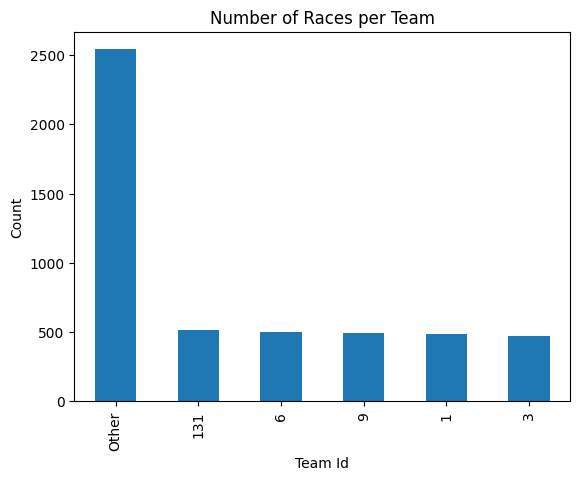

In [187]:
regress_df['constructorId'].value_counts().plot(kind='bar')
plt.xlabel('Team Id')
plt.ylabel('Count')
plt.title('Number of Races per Team')
plt.show()

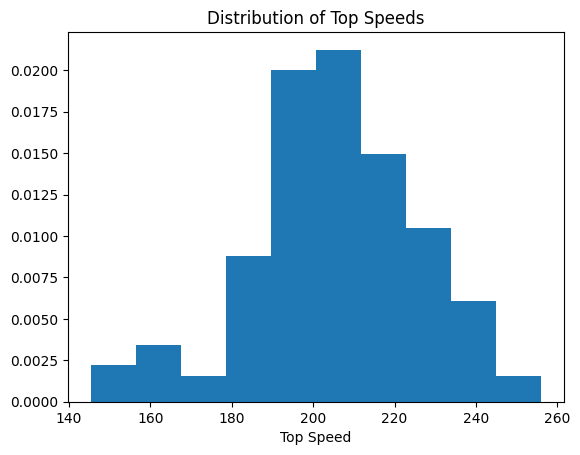

In [188]:
plt.hist(regress_df['fastestLapSpeed'], density=True)
plt.xlabel('Top Speed')
plt.title('Distribution of Top Speeds')
plt.show()

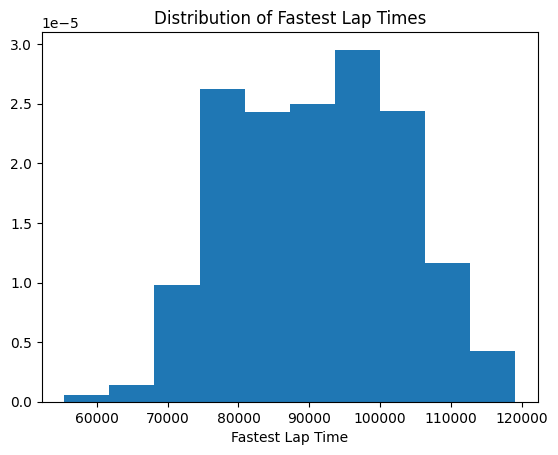

In [189]:
plt.hist(regress_df['fastest_duration'], density=True)
plt.xlabel('Fastest Lap Time')
plt.title('Distribution of Fastest Lap Times')
plt.show()

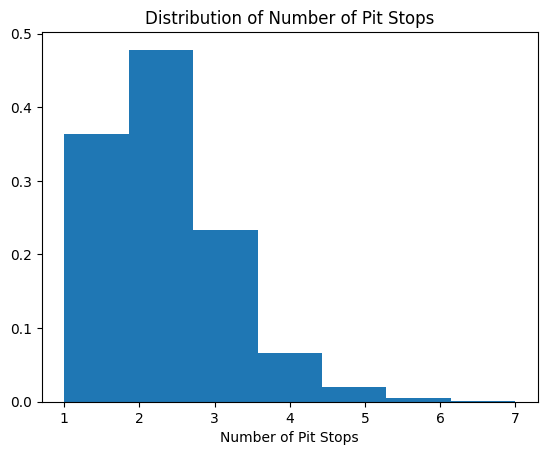

In [194]:
plt.hist(regress_df['stop'], density=True, bins = 7)
plt.xlabel('Number of Pit Stops')
plt.title('Distribution of Number of Pit Stops')
plt.show()

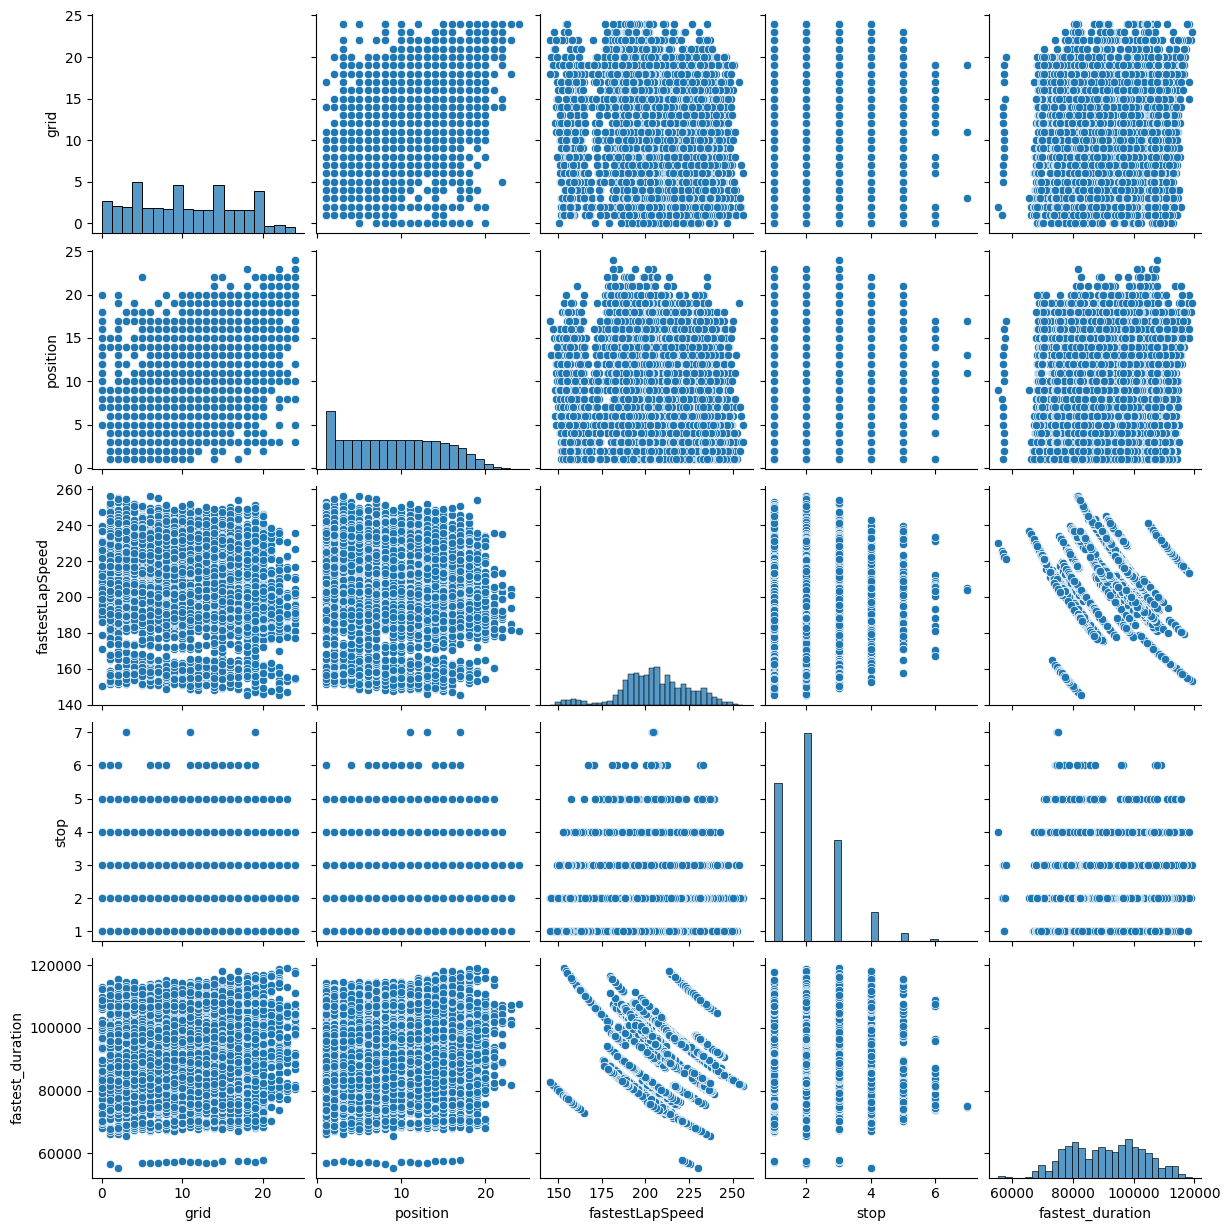

In [200]:
sns.pairplot(regress_df[['grid', 'position', 'fastestLapSpeed', 'stop', 'fastest_duration']])
plt.show()

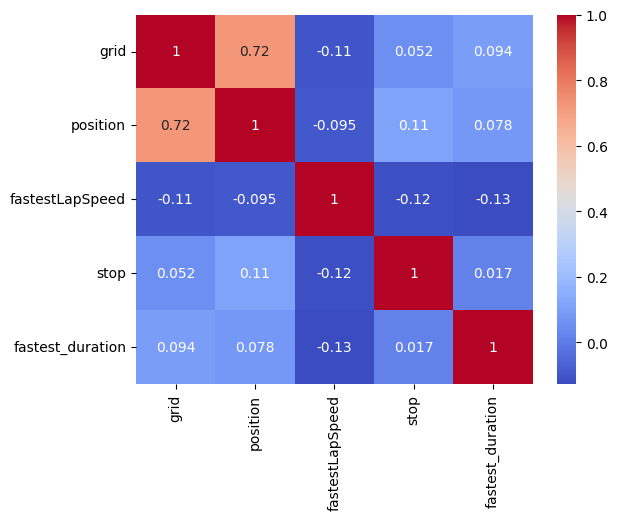

In [195]:
corr = regress_df[['grid', 'position', 'fastestLapSpeed', 'stop', 'fastest_duration']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Regression Analysis

In [196]:
import seaborn as sns
from sklearn.linear_model import LinearRegression

x1 = regression_df['grid']
x2 = regression_df['fastestLapSpeed']
x3 = regression_df['fastest_duration']
x4 = regression_df['stop']
x5 = regression_df['constructorId']

features = [x1,x2,x3,x4,x5]

X = np.array(features).T 
w = regression_df['position']


regression = LinearRegression()  # create object for the class
regression.fit(X,w)  # perform linear regression
model = regression.predict(X)  # make predictions
adj_r2 = 1 - (((1 - regression.score(X,w)) * (len(regression_df) - 1)) / (len(regression_df) - len(features) - 1))

print('coefficients \t',regression.coef_)
print('intercept \t',regression.intercept_)
print('R^2 value \t',regression.score(X,w))
print('Adj R^2 vallue \t', adj_r2)

ValueError: could not convert string to float: 'Other'

In [ ]:
import statsmodels.api as sm

formula_string = "position ~ grid + fastestLapSpeed + fastest_duration + stop + constructorId"

model = sm.formula.ols(formula = formula_string, data = regression_df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:               position   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     831.6
Date:                Tue, 22 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:49:48   Log-Likelihood:                -13197.
No. Observations:                5010   AIC:                         2.641e+04
Df Residuals:                    5000   BIC:                         2.648e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  3